In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN

In [6]:
y = [1, 0, 1]
y_pred = [0.9, 0.2, 0.4]

sum = 0
for i in range(3):
    sum += (y[i]*np.log(y_pred[i]) + (1 - y[i])*np.log(1 - y_pred[i]))
    print(sum)

print(1/3*sum)

-0.10536051565782628
-0.328504066972036
-1.244794798846191
-0.41493159961539694


# Logistic Regression

In [7]:
class LogisticRegression:
    def __init__ (self, lr=0.01, num_iter=1000):
        self.lr = lr
        self.num_iter = num_iter
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
       return 1 / (1 + np.exp(-z))

    def binary_cross_entropy(self, y_true, y_pred):
        epsilon = 1e-9 
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred)
        return -np.mean(loss)

    def grad(self, X, y_true, y_pred):
        n_samples = X.shape[0]
        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_true))
        db = (1 / n_samples) * np.sum(y_pred - y_true)
        return dw, db


    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(z)
        return y_pred

    def predict(self, X, threshold=0.5):
        y_pred = self.predict_proba(X)
        y_pred[y_pred >= threshold] = 1.0
        y_pred[y_pred < threshold] = 0.0
        return y_pred

    def batch_generator(self, X, y, batch_size=32):
        m = X.shape[0]
        idx = np.arange(m)
        np.random.shuffle(idx)
        n_batch = m // batch_size + 1

        for i in range(n_batch):
            i_start = batch_size * i
            i_stop = min((i + 1)* batch_size, m)

            if i_start < i_stop:
                batch_idx = idx[i_start: i_stop]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                yield X_batch, y_batch

            else:
                pass

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        
        for _ in range(self.num_iter):

            for X_batch, y_batch in self.batch_generator(X, y):
                z = np.dot(X_batch, self.weights) + self.bias
                y_pred = self.sigmoid(z)
                
                dw, db = self.grad(X_batch, y_batch, y_pred)

                self.weights -= self.lr * dw
                self.bias -= self.lr * db
            if _ % 100 == 0:
                full_pred = self.predict_proba(X)
                print(f"Epoch {_} - Loss: {self.binary_cross_entropy(y, full_pred):.4f}")

        return self.weights, self.bias

In [8]:
def evaluate_model(y_true, y_pred):
    accuracy = np.mean(y_true == y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score  = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1_score:.2f}")


# Diabetes

In [9]:
data_diabetes = pd.read_csv('diabetes.csv')
data_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
X = data_diabetes[data_diabetes.columns[:-1]].values
y = data_diabetes[data_diabetes.columns[-1]].values
# smote = SMOTE(random_state=42,
#               k_neighbors=7)
# X_new, y_new = smote.fit_resample(X, y)

ada = ADASYN(random_state=42,
             n_neighbors=5)
X_new, y_new = ada.fit_resample(X, y)

print(X_new.shape)
print(y_new.shape)

(974, 8)
(974,)


/home/anhh/miniconda3/envs/face_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2)

scaler = StandardScaler()
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

In [12]:
model = LogisticRegression(lr=0.01, num_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test, threshold=0.36)
evaluate_model(y_test, y_pred)

Epoch 0 - Loss: 0.6669
Epoch 100 - Loss: 0.5181
Epoch 200 - Loss: 0.5175
Epoch 300 - Loss: 0.5175
Epoch 400 - Loss: 0.5175
Epoch 500 - Loss: 0.5175
Epoch 600 - Loss: 0.5175
Epoch 700 - Loss: 0.5175
Epoch 800 - Loss: 0.5175
Epoch 900 - Loss: 0.5175
Accuracy: 71.79%
Precision: 0.71
Recall: 0.78
F1 Score: 0.74


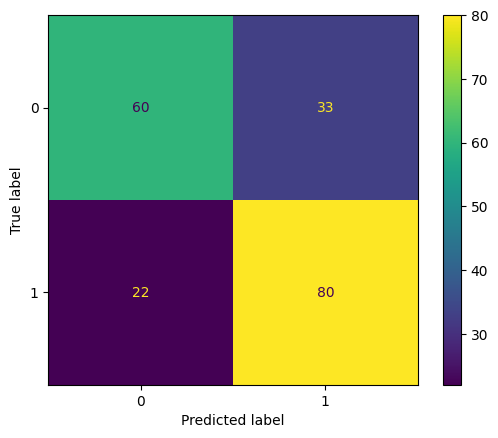

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

# Wine Quality

In [14]:
data = pd.read_csv('winequality-red.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [15]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [16]:
X = data[data.columns[:-1]].values
y = data[data.columns[-1]].values

y = np.where(y > 5, 1, 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
model = LogisticRegression(lr=0.01, num_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test, threshold=0.53)
evaluate_model(y_test, y_pred)

Epoch 0 - Loss: 0.6508
Epoch 100 - Loss: 0.5076
Epoch 200 - Loss: 0.5072
Epoch 300 - Loss: 0.5071
Epoch 400 - Loss: 0.5071
Epoch 500 - Loss: 0.5071
Epoch 600 - Loss: 0.5071
Epoch 700 - Loss: 0.5071
Epoch 800 - Loss: 0.5071
Epoch 900 - Loss: 0.5071
Accuracy: 72.81%
Precision: 0.75
Recall: 0.74
F1 Score: 0.75


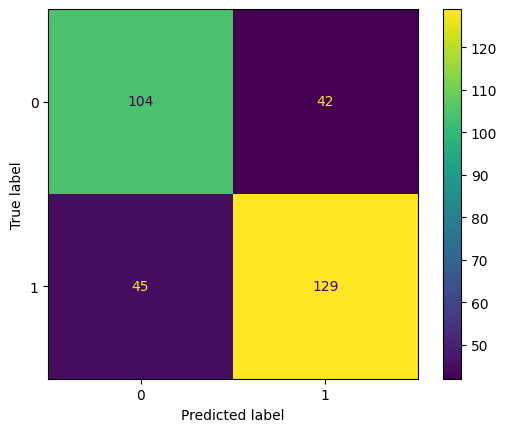

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

# Lab3 2

In [19]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE, ADASYN
import matplotlib.pyplot as plt

In [20]:
X, y = make_classification(n_samples=400,
                           n_features=2,
                           n_redundant=0,
                           n_informative=2,
                           weights=[0.3, 0.7],
                           random_state=36)
X.shape, y.shape

((400, 2), (400,))

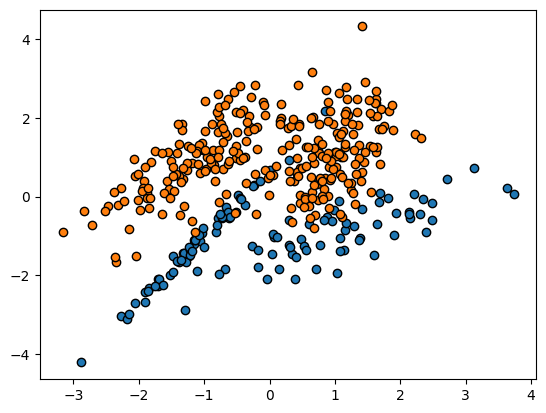

In [21]:
plt.scatter(X[y==0, 0], X[y==0, 1], marker='o', edgecolors='k')
plt.scatter(X[y==1, 0], X[y==1, 1], marker='o', edgecolors='k')

In [22]:
smote = SMOTE(random_state=36,
              k_neighbors=7)

X_new, y_new = smote.fit_resample(X, y)
X_new.shape, y_new.shape

/home/anhh/miniconda3/envs/face_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


((562, 2), (562,))

In [23]:
(y==0).sum(), (y==1).sum()

(119, 281)

In [24]:
(y_new==0).sum(), (y_new==1).sum()

(281, 281)

/tmp/ipykernel_244827/3885472114.py:6: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_new[:, 0], X_new[:, 1], marker='x', edgecolors='k')


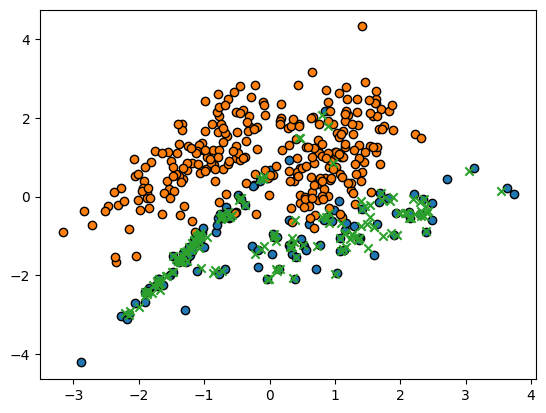

In [25]:
X_new = X_new[len(X):]
y_new = y_new[len(X):]

plt.scatter(X[y==0, 0], X[y==0, 1], marker='o', edgecolors='k')
plt.scatter(X[y==1, 0], X[y==1, 1], marker='o', edgecolors='k')
plt.scatter(X_new[:, 0], X_new[:, 1], marker='x', edgecolors='k')

# Bai 3

In [26]:
data = pd.read_csv('creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [27]:
X = data[data.columns[:-1]].values
y = data[data.columns[-1]].values

X.shape, y.shape

((284807, 30), (284807,))

In [28]:
(y==0).sum(), (y==1).sum()

(284315, 492)

In [29]:
smote = SMOTE(random_state=42,
              k_neighbors=7)
X_new, y_new = smote.fit_resample(X, y)
X_new.shape, y_new.shape

/home/anhh/miniconda3/envs/face_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


((568630, 30), (568630,))

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
model = LogisticRegression(lr=0.01, num_iter=900)
model.fit(X_train, y_train)
y_pred = model.predict(X_test, threshold=0.53)
evaluate_model(y_test, y_pred)

Epoch 0 - Loss: 0.1013
Epoch 100 - Loss: 0.0637
Epoch 200 - Loss: 0.0615
Epoch 300 - Loss: 0.0606
Epoch 400 - Loss: 0.0600
Epoch 500 - Loss: 0.0596
Epoch 600 - Loss: 0.0594
Epoch 700 - Loss: 0.0592
Epoch 800 - Loss: 0.0590
Accuracy: 97.93%
Precision: 0.99
Recall: 0.97
F1 Score: 0.98
